In [1]:
import SimpleITK as sitk
import numpy as np
import os
import shutil
import h5py
import matplotlib.pyplot as plt
import glob
import sys
sys.path.append('..')
from src.utils import crop_im

## First need to check that when making multilabel mask, there are no overlaps between medial and lateral

In [2]:
DATA_DIR = '../data/IWOAI'

# Paths
train_im_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*.im')))
train_seg_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*.seg')))

val_im_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'valid', '*.im')))
val_seg_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'valid', '*.seg')))

print(f'Number of training images: {len(train_im_paths)}; segmentations: {len(train_seg_paths)}')
print(f'Number of validation images: {len(val_im_paths)}; segmentations: {len(val_seg_paths)}')

all_im_paths = train_im_paths + val_im_paths
all_seg_paths = train_seg_paths + val_seg_paths

Number of training images: 120; segmentations: 120
Number of validation images: 28; segmentations: 28


In [9]:
# cycle through segmentations to see if there is any overlap between medial and lateral
for seg_path in all_seg_paths:
    with h5py.File(seg_path, 'r') as f:
        seg = np.array(f['data'])

    med_mask = seg[..., -1]
    lat_mask = seg[..., -2]

    if np.any(med_mask & lat_mask):
        print(f'Overlap found in {seg_path}')

## check axis order of already transformed data

In [12]:
# Load the already-converted .nii.gz file
nii_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/imagesTr/IWOAI_001_0000.nii.gz'
nii_volume = sitk.ReadImage(nii_path)

# Get the metadata
print("Image size:", nii_volume.GetSize())
print("Spacing (x, y, z):", nii_volume.GetSpacing())  # Includes pixel spacing and slice thickness
print("Origin:", nii_volume.GetOrigin())
print("Direction:", nii_volume.GetDirection())


Image size: (256, 200, 160)
Spacing (x, y, z): (0.36500000953674316, 0.36500000953674316, 0.699999988079071)
Origin: (0.0, 0.0, 0.0)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


## only spacing was set - as 0.365, 0.365, 0.7

## Copy from previous task to new dataset folder

In [11]:
# train image folder to copy from
src_folder = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/imagesTr'

# new dataset folder to copy to
dst_folder = '../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/imagesTr'

# copy folder structure
shutil.copytree(src_folder, dst_folder)

'../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/imagesTr'

In [12]:
# do same for test images
src_folder = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/imagesTs'
dst_folder = '../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/imagesTs'
shutil.copytree(src_folder, dst_folder)

'../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/imagesTs'

## Now read in all masks and turn to lateral/medial multiclass mask.
## Save in labelsTr

In [22]:
# train labels path
dst_labels_folder = '../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/labelsTr'
os.makedirs(dst_labels_folder, exist_ok=True)

spacing = (0.365, 0.365, 0.70)

for i, seg_path in enumerate(all_seg_paths):
    with h5py.File(seg_path, 'r') as f:
        seg = np.array(f['data'])

    # Create new multiclass mask
    # Assuming original labels: 0=background, -2=lateral meniscus, -1=medial meniscus
    multiclass_mask = np.zeros(seg.shape[:-1], dtype=np.uint8)
    multiclass_mask[seg[..., -2] > 0] = 1  # lateral meniscus
    multiclass_mask[seg[..., -1] > 0] = 2  # medial meniscus

    # crop
    cropped_mask = crop_im(multiclass_mask)

    # Reorder dimensions
    reordered_mask = np.moveaxis(cropped_mask, -1, 0)
    
    # Turn into sitk image
    sitk_mask = sitk.GetImageFromArray(reordered_mask)
    
    # Set spacing
    sitk_mask.SetSpacing(spacing)
    
    # Save mask
    sitk.WriteImage(sitk_mask, os.path.join(dst_labels_folder, f'IWOAI_{str(i+1).zfill(3)}.nii.gz'))
    

## Test masks are binary so just copy them across

In [24]:
# copy test labels
src_test_labels_folder = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/labelsTs'
dst_test_labels_folder = '../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/labelsTs'
shutil.copytree(src_test_labels_folder, dst_test_labels_folder)

'../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/labelsTs'

# check a few image/mask pairs to double check

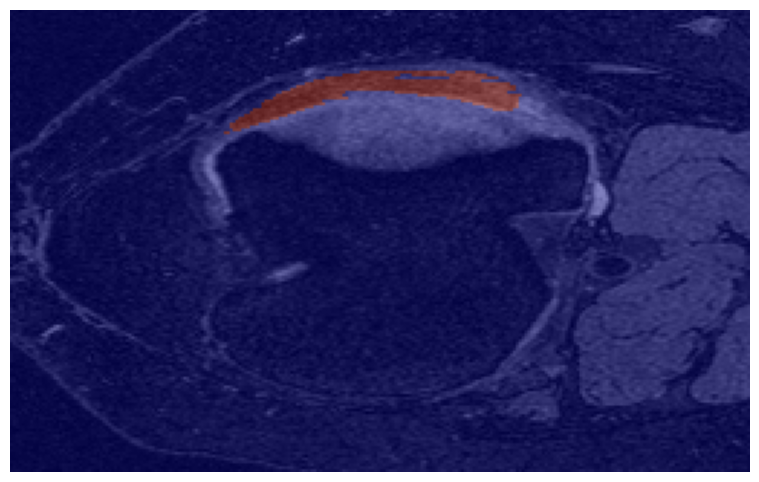

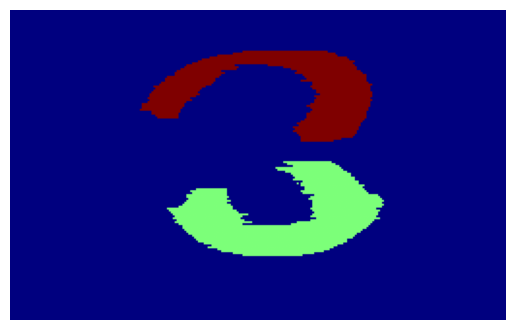

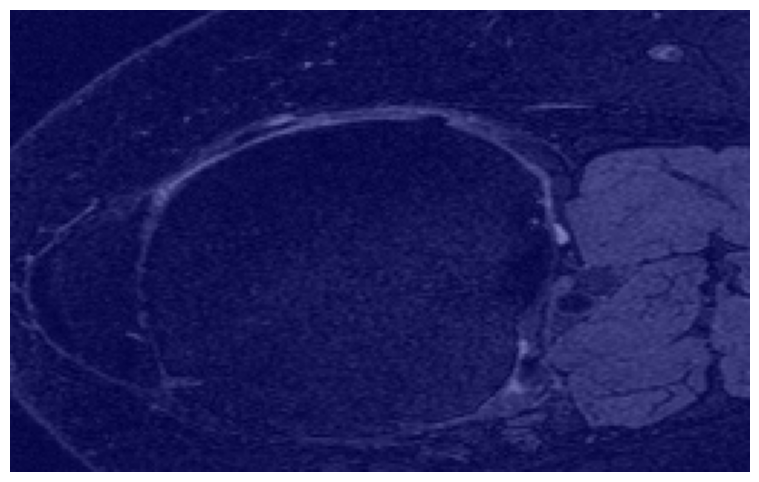

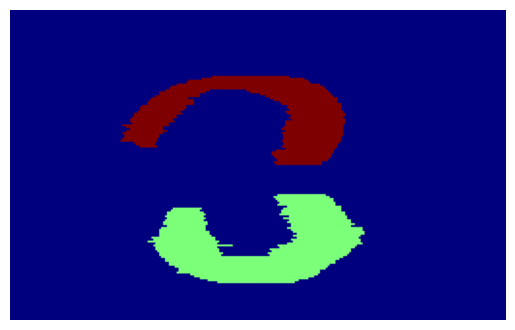

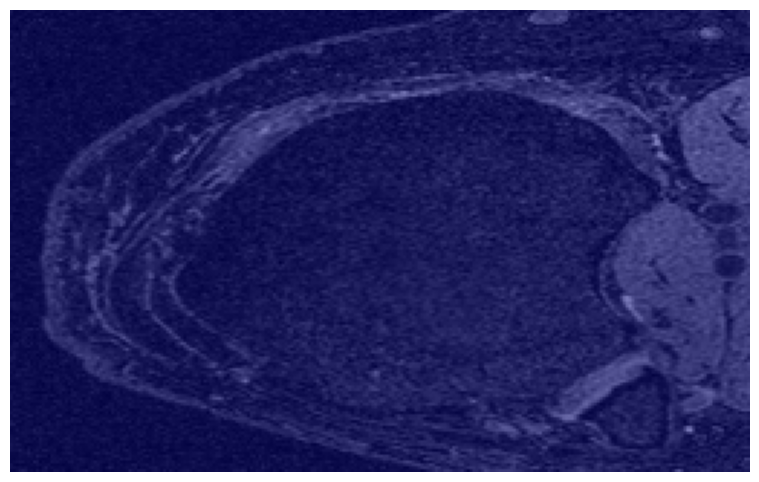

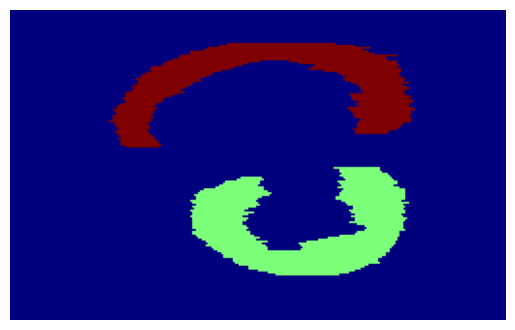

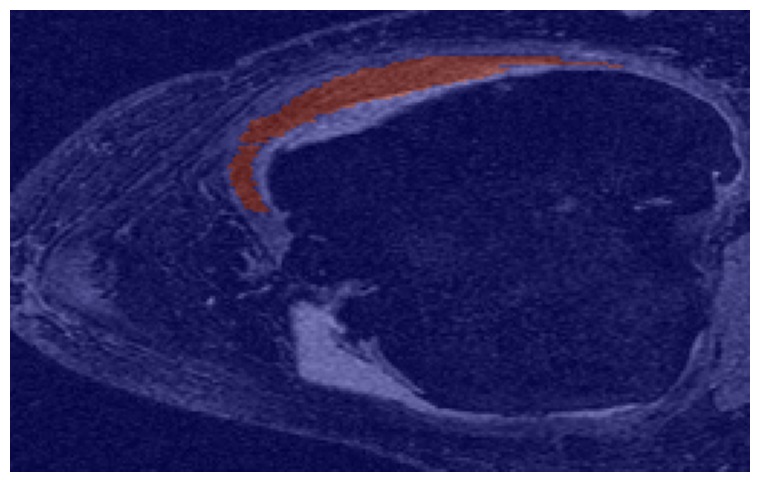

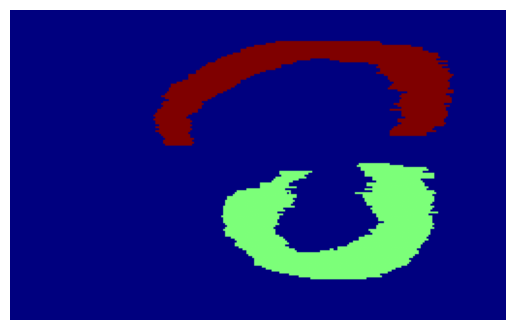

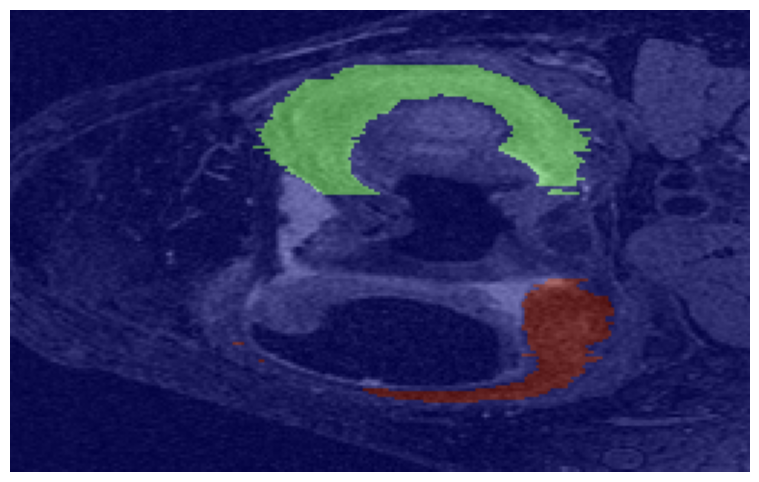

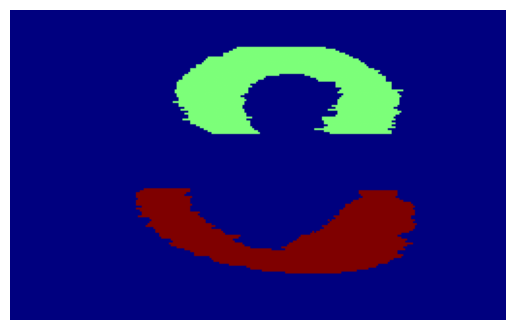

In [6]:
# pick a few image/mask pairs to double check
nnunet_im_paths = sorted(glob.glob('../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/imagesTr/*.nii.gz'))
nnunet_mask_paths = sorted(glob.glob('../nnUNet_data/nnUNet_raw/Dataset362_Menisci_multiclass/labelsTr/*.nii.gz'))

for im_path, mask_path in zip(nnunet_im_paths[:5], nnunet_mask_paths[:5]):
    im = sitk.ReadImage(im_path)
    mask = sitk.ReadImage(mask_path)
    
    im_array = sitk.GetArrayFromImage(im)
    mask_array = sitk.GetArrayFromImage(mask)
    
    slice_idx = 120
    
    plt.figure(figsize=(12, 6))
    plt.imshow(im_array[:, slice_idx, :], cmap='gray')
    plt.imshow(mask_array[:, slice_idx, :], cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

    # now collapse to 2D and check
    plt.imshow(np.max(mask_array, axis=1), cmap='jet')
    plt.axis('off')